In [1]:
import pyart
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import cartopy.crs as ccrs
from pyproj import Proj, CRS, Transformer
import glob
import xarray as xr
from datetime import datetime, timedelta
import pandas as pd
from scipy.interpolate import griddata
from collections import defaultdict
from scipy.spatial import KDTree
import os
from sklearn.neighbors import KNeighborsRegressor
from matplotlib import colors
from scipy.ndimage import gaussian_filter1d


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [13]:
# Returns forward, central, and backward difference-based averages of a 2D array, for numerical integration
def weightedAvg(y):
    y = np.asarray(y)
    nx, ny, nt = y.shape
    avg = np.full_like(y, np.nan, dtype=np.float64)

    # Forward difference at index 0
    y0 = y[:, :, 0]
    y1 = y[:, :, 1]
    weights = (~np.isnan(y0)).astype(float) * 2 + (~np.isnan(y1)).astype(float)
    vals = np.nan_to_num(y0) * 2 + np.nan_to_num(y1)
    avg[:, :, 0] = np.where(weights > 0, vals / weights, np.nan)

    # Central differences
    for i in range(1, nt - 1):
        ym = y[:, :, i - 1]
        yc = y[:, :, i]
        yp = y[:, :, i + 1]

        weights = (
            (~np.isnan(ym)).astype(float) +
            2 * (~np.isnan(yc)).astype(float) +
            (~np.isnan(yp)).astype(float)
        )
        vals = (
            np.nan_to_num(ym) +
            2 * np.nan_to_num(yc) +
            np.nan_to_num(yp)
        )
        avg[:, :, i] = np.where(weights > 0, vals / weights, np.nan)

    # Backward difference at index -1
    y_1 = y[:, :, -1]
    y_2 = y[:, :, -2]
    weights = (~np.isnan(y_2)).astype(float) + 2 * (~np.isnan(y_1)).astype(float)
    vals = np.nan_to_num(y_2) + 2 * np.nan_to_num(y_1)
    avg[:, :, -1] = np.where(weights > 0, vals / weights, np.nan)

    return avg

In [3]:
# Important parameters
a = 18 
aHigh = 43
aLow = 11
b = 1.1

theta = 18
 



In [4]:
latGrid_full = np.empty((106, 250, 31))
lonGrid_full = np.empty((106, 250, 31))
rangeGrid_full = np.empty((106, 250, 31))
azGrid_full = np.empty((106, 250, 31))
dbzGrid_full = np.empty((106, 250, 31))
elvCorr_full = np.empty((106, 250, 31))
elvGrid_full = np.empty((106, 250, 31))
vertProf_full = np.empty((106, 250, 31))
snowfallRate_full = np.empty((106, 250, 31))
dailyAccum_full = np.empty((106, 250, 31))

In [14]:
# Access directories
year = '2025'
month = '03'

for i in range(31):
    day = f"{i+1:02d}"

    scanningDir = '/gws/nopw/j04/tone_ico_gws/data/tone-ico_doppler_scanning_cloud_radar/L0/Y'+year+'/M'+month+'/D'+day+'/*el_18*PPI.LV1.NC'
    scanningFiles = sorted(glob.glob(scanningDir))  

    # Data processing for the 2D scanning radar
    latGrid = np.empty((106, 250, 24))
    lonGrid = np.empty((106, 250, 24))
    dbzGrid = np.empty((106, 250, 24))
    dbzCorr = np.empty((106, 250, 24))
    elvCorr = np.empty((106, 250, 24))
    elvGrid = np.empty((106, 250, 24))
    vertProf = np.empty((106, 250, 24))
    snowfallRate = np.empty((106, 250, 24))
    hourlyAccum = np.empty((106, 250, 24))

    latGrid[:] = np.nan
    lonGrid[:] = np.nan
    dbzGrid[:] = np.nan
    dbzCorr[:] = np.nan
    elvCorr[:] = np.nan
    elvGrid[:] = np.nan
    vertProf[:] = np.nan
    snowfallRate[:] = np.nan
    hourlyAccum[:] = np.nan



    # iterating over all the hourly radar scans during the given day, and storing in a common data structure on a common grid
    k = 0
    for file in scanningFiles[:]:
        ds = xr.open_dataset(file)

        # Stack all CZE variables along the range dimension
        cze_vars = ['C1ZE45', 'C2ZE45', 'C3ZE45', 'C4ZE45']
        data_list = [ds[var].values for var in cze_vars]
        range_list = [ds[var.replace('ZE45', 'Range')].values for var in cze_vars]  

        trollLat = ds['GPSLat'].values
        trollLon = ds['GPSLon'].values

        # Concatenate data and ranges
        data_stacked = 10 * np.log10(np.concatenate(data_list, axis=1))  # shape: (n_az, total_range)
        ranges_stacked = np.concatenate(range_list)       # shape: (total_range,)

        # Set all values below -30 to NaN
        #data_stacked[data_stacked < -30] = np.nan

        times = np.array(ds['Time'].values)
        scanTime = times[0]
        base_time = datetime(2001, 1, 1)
        dt = base_time + timedelta(seconds=int(scanTime))
        hour = dt.hour
        #print(times)

        # Generate synthetic azimuths (assuming evenly spaced)
        n_az = ds['Time'].size
        azimuths = np.linspace(0, 2 * np.pi, n_az, endpoint=False)

        # Create 2D grids for polar plot
        azimuths_2d, ranges_2d = np.meshgrid(azimuths, ranges_stacked, indexing='ij')

        # Elevation extraction
        el_deg = np.array(ds.variables['Elv'])
        elvs = np.sin(np.deg2rad(theta)) * ranges_2d

        # Projection to lat/lon
        
        X = ranges_2d * np.cos(azimuths_2d)   # Cartesian x
        Y = ranges_2d * np.sin(azimuths_2d)   # Cartesian y

        crs_centered = CRS.from_proj4(f"+proj=aeqd +lat_0={trollLat} +lon_0={trollLon} +datum=WGS84 +units=m +no_defs")
        crs_geo = CRS.from_epsg(4326)  # WGS84 lat/lon

        transformer = Transformer.from_crs(crs_centered, crs_geo, always_xy=True)

        lon, lat = transformer.transform(X, Y)

        # Initial assignment
        latGrid[:, :, hour] = lat[:106, :250]  
        lonGrid[:, :, hour] = lon[:106, :250]
        dbzGrid[:, :, hour] = data_stacked[:106, :250]
        elvGrid[:, :, hour] = elvs[:106, :250]

        # Elevation correction #2: using the scanning radar's own vertical profile
        rangeAvg = np.nanmean(dbzGrid[:, :, hour], axis=0)
        vertProf[:, :, hour] = rangeAvg
        
        elv1d = np.nanmean(elvGrid[:, :, hour], axis=0)
        baseRange = np.nanmean(rangeAvg[:5])

        elvCorr[:, :, hour] = baseRange - rangeAvg
        k = k + 1

    elvCorr_smooth = gaussian_filter1d(elvCorr, sigma=10.0, axis=1, mode='reflect')
    vertProf_smooth = gaussian_filter1d(vertProf, sigma=10.0, axis=1, mode='reflect')
    dbzCorr = elvCorr_smooth + dbzGrid

    snowfallRate_0313 = ((10 ** (dbzCorr / 10)) / a) ** (1 / b)
    hourlyAccum_0313 = weightedAvg(snowfallRate_0313)

    latGrid_full[:, :, i] = np.mean(latGrid, axis=2)
    lonGrid_full[:, :, i] = np.mean(lonGrid, axis=2)
    dailyAccum_full[:, :, i] = np.nansum(hourlyAccum_0313, axis=2)
    

In [ ]:
# Grid layout for 24 subplots, e.g. 6 rows x 4 cols
n_rows, n_cols = 6, 4

fig = plt.figure(figsize=(20, 30))


for day in range(31):
    ax = fig.add_subplot(n_rows, n_cols, hour+1, projection=ccrs.SouthPolarStereo())
    
    # Set gridlines and extent
    ax.gridlines(draw_labels=True)
    ax.set_extent([2, 3, -72.15, -71.85], crs=ccrs.PlateCarree())
    ax.coastlines()
    
    # Plot data for the hour; assuming dbzCorrected_0313 is 3D: (lat, lon, time)
    pcm = ax.pcolormesh(
        latGrid[:, :, 0], lonGrid[:, :, 0], dailyAccum_full[:, :, day], 
        cmap='viridis', 
        transform=ccrs.PlateCarree()
    )
    
    ax.set_title(f'Hour {hour:02d}:00', fontsize=16)

# Add one big colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm, cax=cbar_ax, label='Hourly accumulation (mm)')
cbar.set_label('Hourly accumulation (mm)', fontsize=16)
cbar.ax.tick_params(labelsize=16)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar

[[-72.01042937 -72.01042935 -72.01042931 ... -72.00995399 -72.00995016
  -72.00994632]
 [-72.01039772 -72.01036605 -72.01033435 ... -72.00207419 -72.00203873
  -72.00200325]
 [-72.01036618 -72.01030296 -72.01023973 ... -71.99422537 -71.99415841
  -71.99409143]
 ...
 [-72.01052389 -72.01061838 -72.01071286 ... -72.03350261 -72.03359341
  -72.0336842 ]
 [-72.01049257 -72.01055574 -72.0106189  ... -72.02569588 -72.02575529
  -72.0258147 ]
 [-72.01046103 -72.01049266 -72.01052427 ... -72.01783712 -72.01786496
  -72.01789278]]


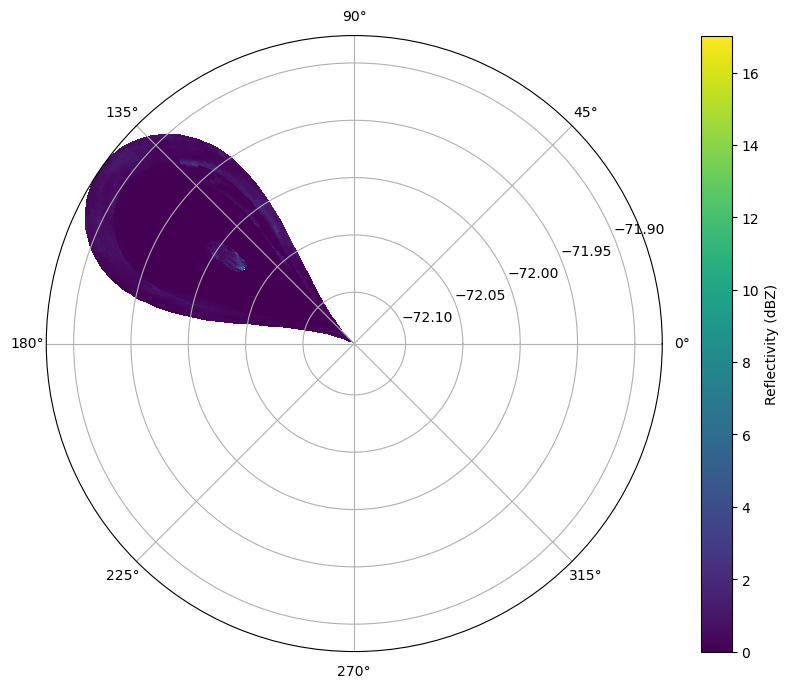

In [25]:
# Plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(10, 8))
pcm = ax.pcolormesh(
    lonGrid[:, :, 0], latGrid[:, :, 0], dailyAccum_full[:, :, 0], 
    cmap='viridis', 
)
plt.colorbar(pcm, ax=ax, label='Reflectivity (dBZ)')

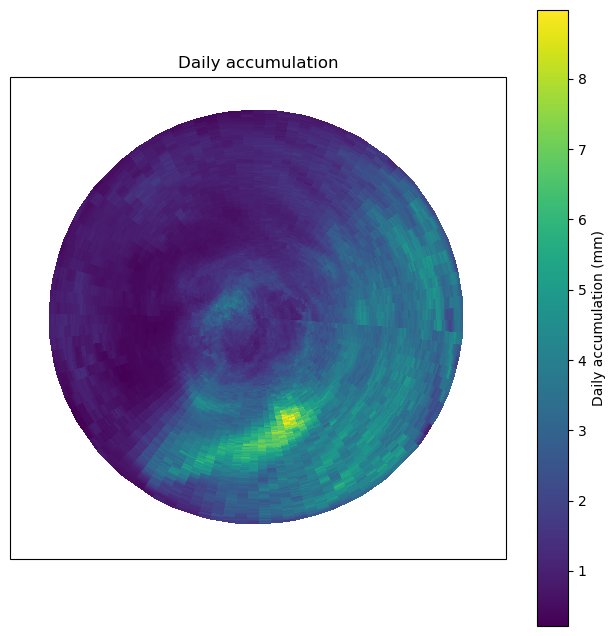

In [34]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([trollLon-0.5, trollLon+0.5, trollLat-0.15, trollLat+0.15], crs=ccrs.PlateCarree())
ax.coastlines()

cf = ax.pcolormesh(lonGrid[:, :, 0], latGrid[:, :, 0], dailyAccum_full[:, :, 13], transform=ccrs.PlateCarree(), cmap='viridis')
plt.colorbar(cf, label='Daily accumulation (mm)')
plt.title("Daily accumulation")

plt.show()

In [30]:
monthlyAccum = np.sum(dailyAccum_full, axis=2)

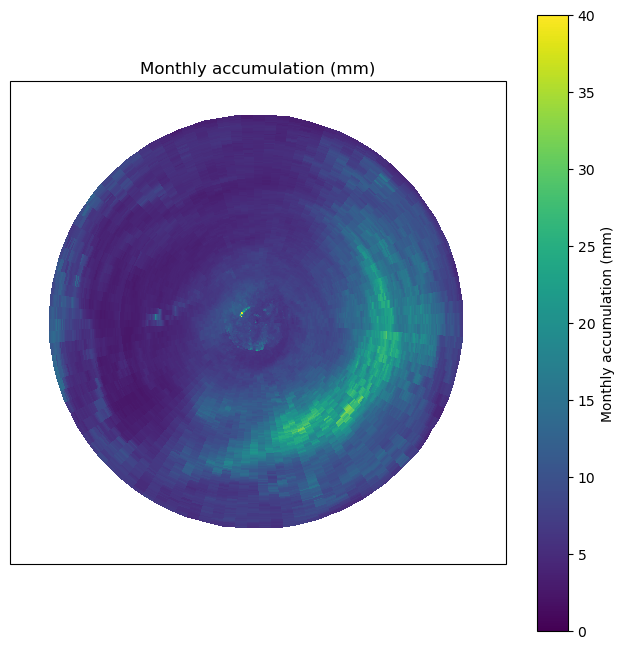

In [35]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([trollLon-0.5, trollLon+0.5, trollLat-0.15, trollLat+0.15], crs=ccrs.PlateCarree())
ax.coastlines()

cf = ax.pcolormesh(lonGrid[:, :, 0], latGrid[:, :, 0], monthlyAccum, vmin=0, vmax=40, transform=ccrs.PlateCarree(), cmap='viridis')
plt.colorbar(cf, label='Monthly accumulation (mm)')
plt.title("Monthly accumulation (mm)")

plt.show()

In [43]:
# Data processing ERA5

modfile_path = '/gws/nopw/j04/tone_ico_gws/cloudnet/troll/era5/8c77d7d4c6e1d8b637bca6cfa6a85450.nc'
model = nc.Dataset(modfile_path)

fullGrid = np.array(model.variables['mxtpr'][:744, :, :]) * 60 * 60
eraLat = np.array(model.variables['latitude'][:]) 
eraLon = np.array(model.variables['longitude'][:]) 

monthlyEra = np.sum(fullGrid, axis=0)

In [46]:
print(fullGrid.shape)

(744, 121, 1440)


In [45]:
print(monthlyEra.shape)

(121, 1440)


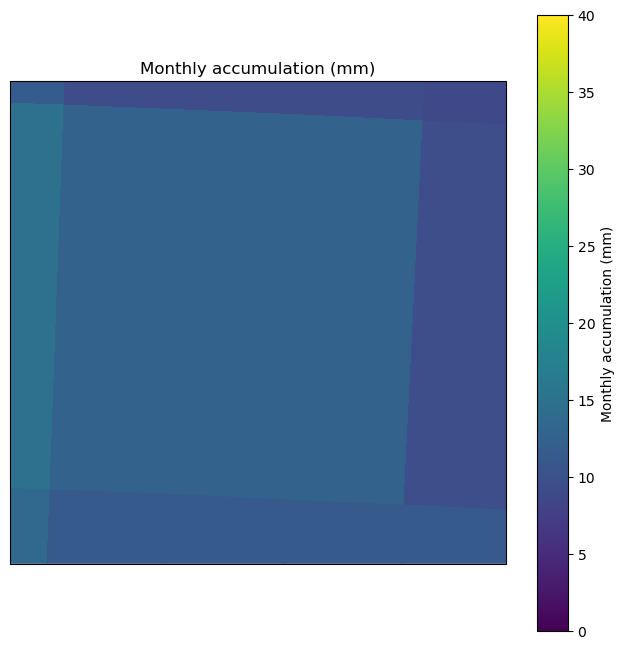

In [44]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([trollLon-0.5, trollLon+0.5, trollLat-0.15, trollLat+0.15], crs=ccrs.PlateCarree())
ax.coastlines()

cf = ax.pcolormesh(eraLon, eraLat, monthlyEra, vmin=0, vmax=40, transform=ccrs.PlateCarree(), cmap='viridis')
plt.colorbar(cf, label='Monthly accumulation (mm)')
plt.title("Monthly accumulation (mm)")

plt.show()